## Linear Regression example - Boston Housing Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

*Number of attributes:* 13 numeric/categorical predictive. Median value is usually the target.

**Attribute Information**:

 - CRIM: per capita crime rate by town
 - ZN: proportion of residential land zoned for lots over 25,000 sq.ft.
 - INDUS: proportion of non-retail business acres per town]
 - CHAS: Charles River dummy variable (=1 if tract bounds river; 0 otherwise)
 - NOX: Nitric oxides concentration (parts per 10 million)
 - RM: Average number of rooms per dwelling
 - AGE: Proportion of owner-occupied units built prior to 1940
 - DIS: Weighted distances of five Boston employment centres
 - RAD: Index of accessibility to radial highways
 - TAX: Full value property-tax rate per 10,000 dollars
 - PTRATIO: Pupil-teacher ratio by town
 - B: 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
 - LSTAT: % lower status of the population
 - MEDV: Median value of owner-occupied homes in $1000's

In [28]:
boston = pd.DataFrame(data, columns=['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'])
boston.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [34]:
boston['MEDV'] = target

In [36]:
boston

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


In [35]:
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


#### Exploratory Data Analysis

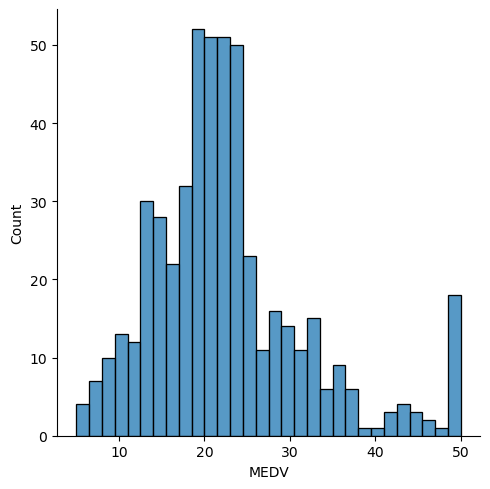

In [37]:
sns.displot(boston['MEDV'], bins=30);

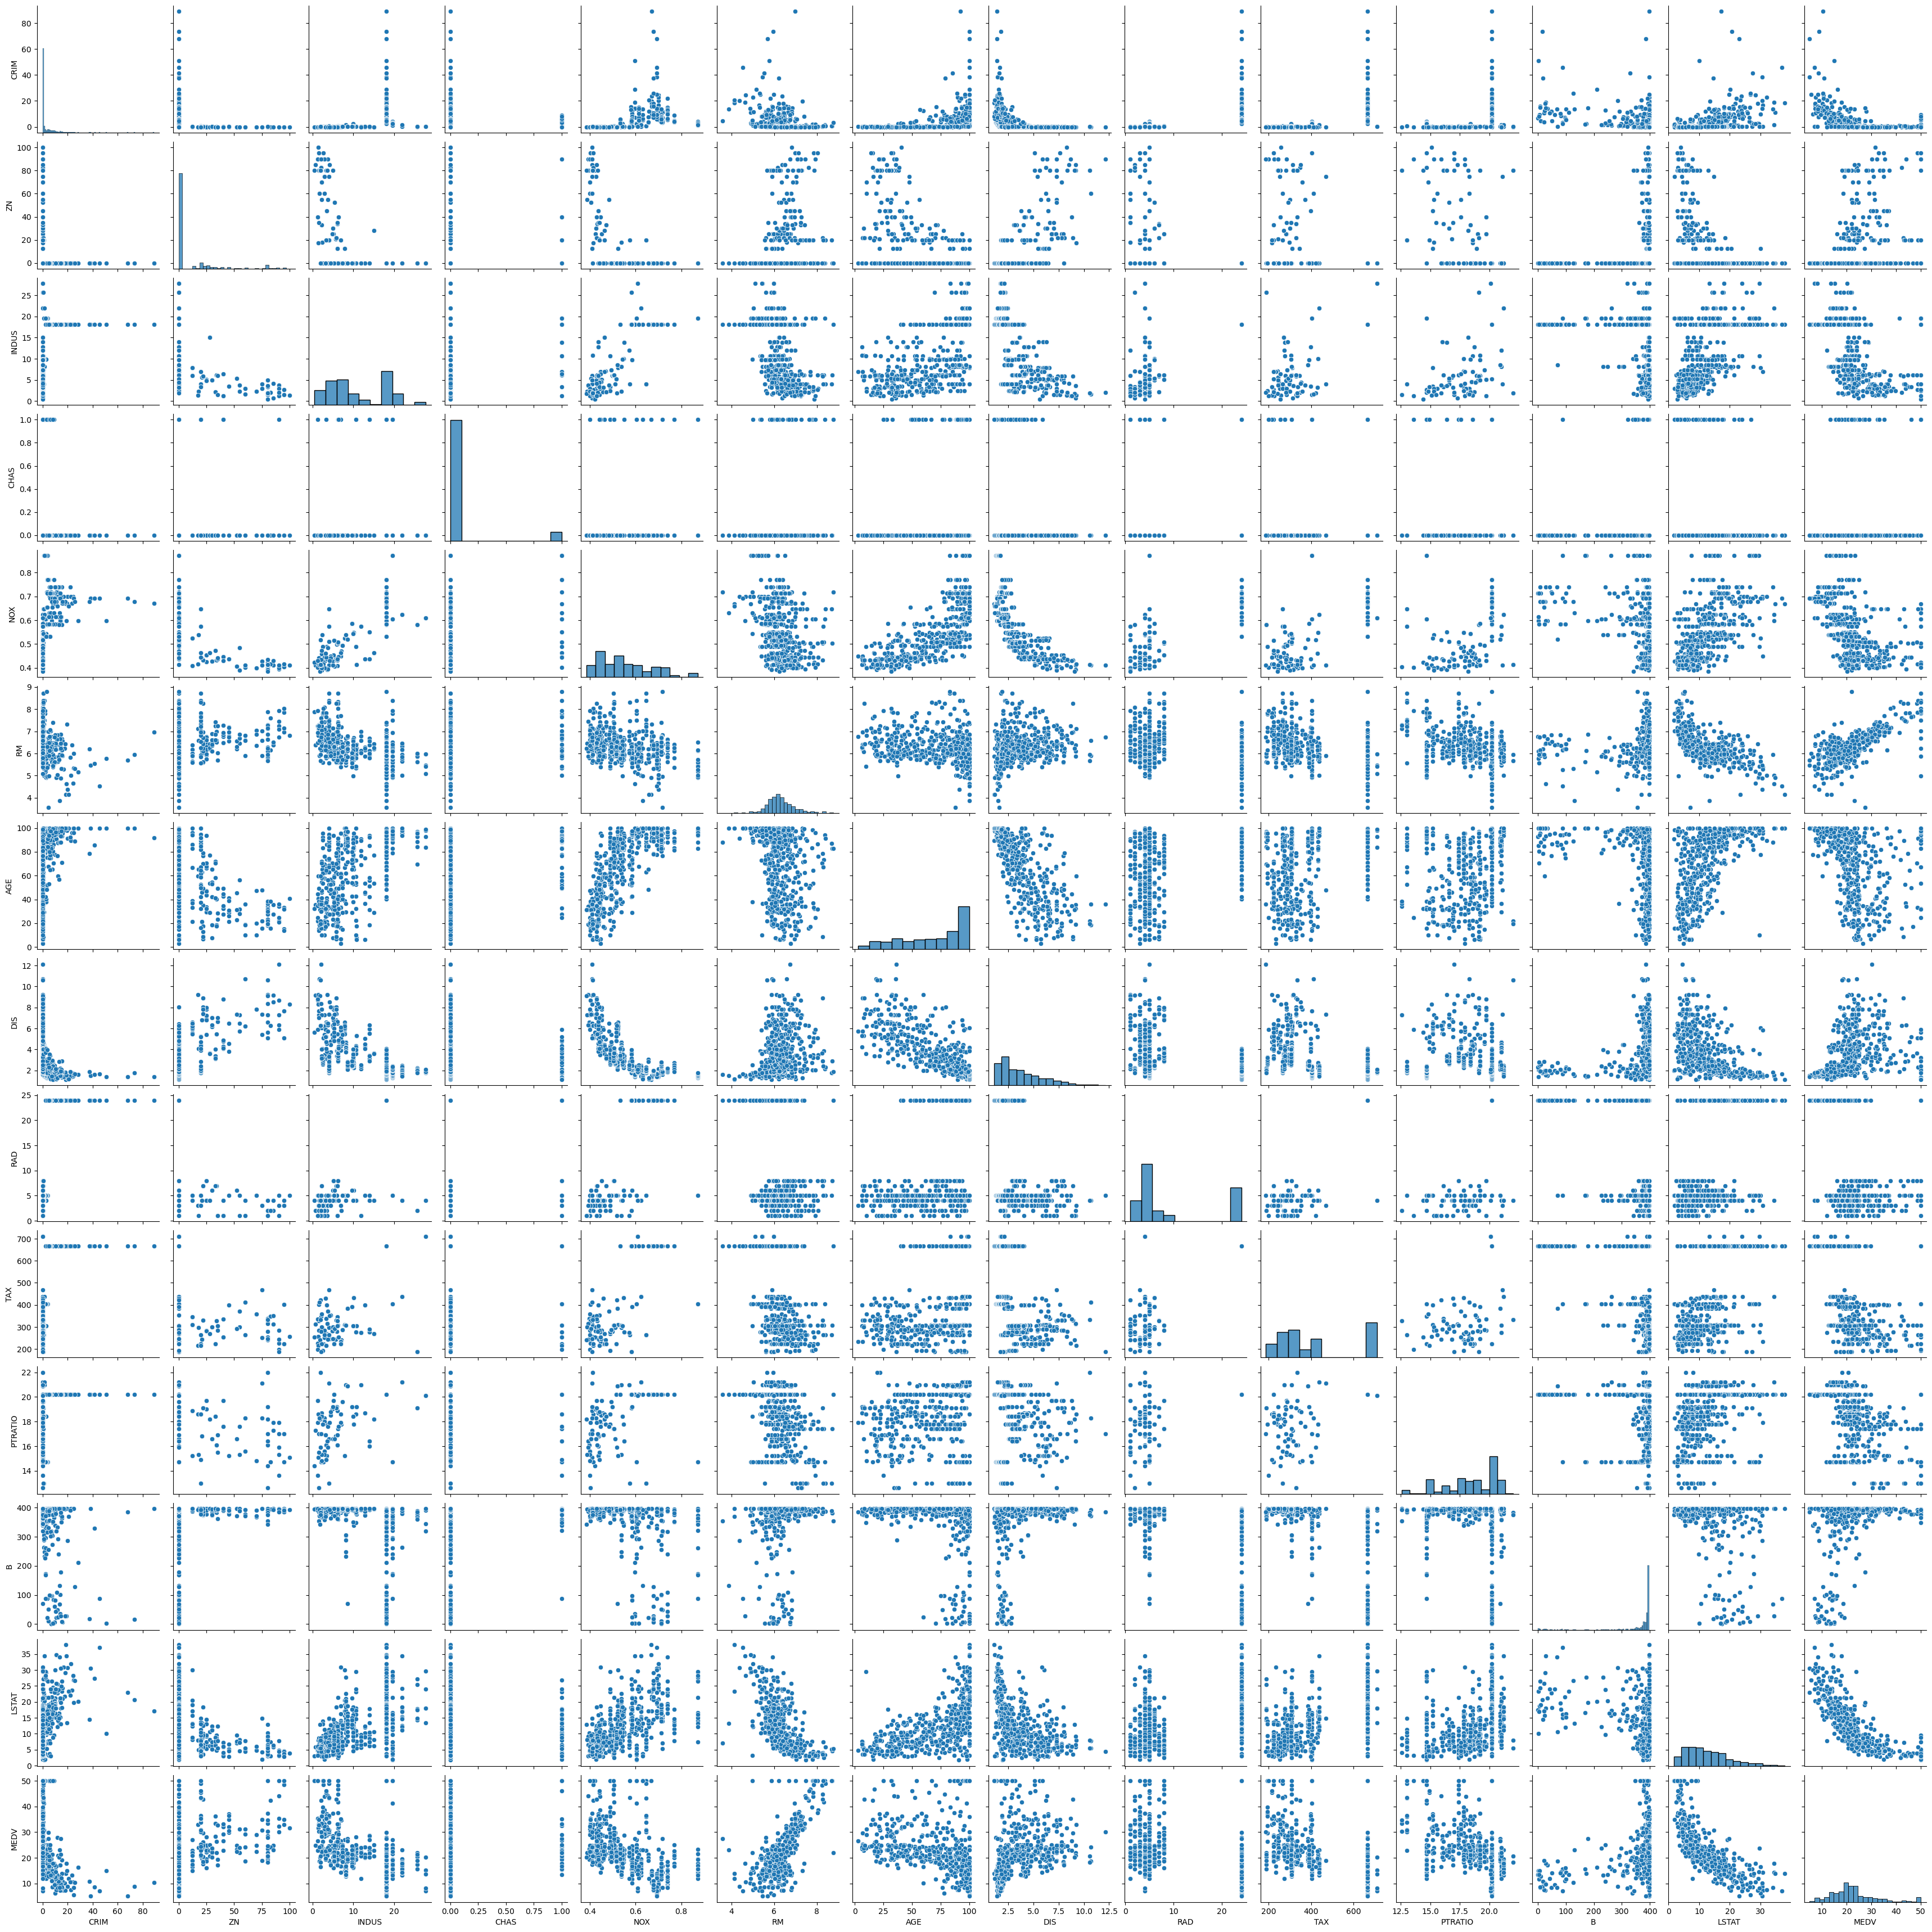

In [38]:
sns.pairplot(boston)

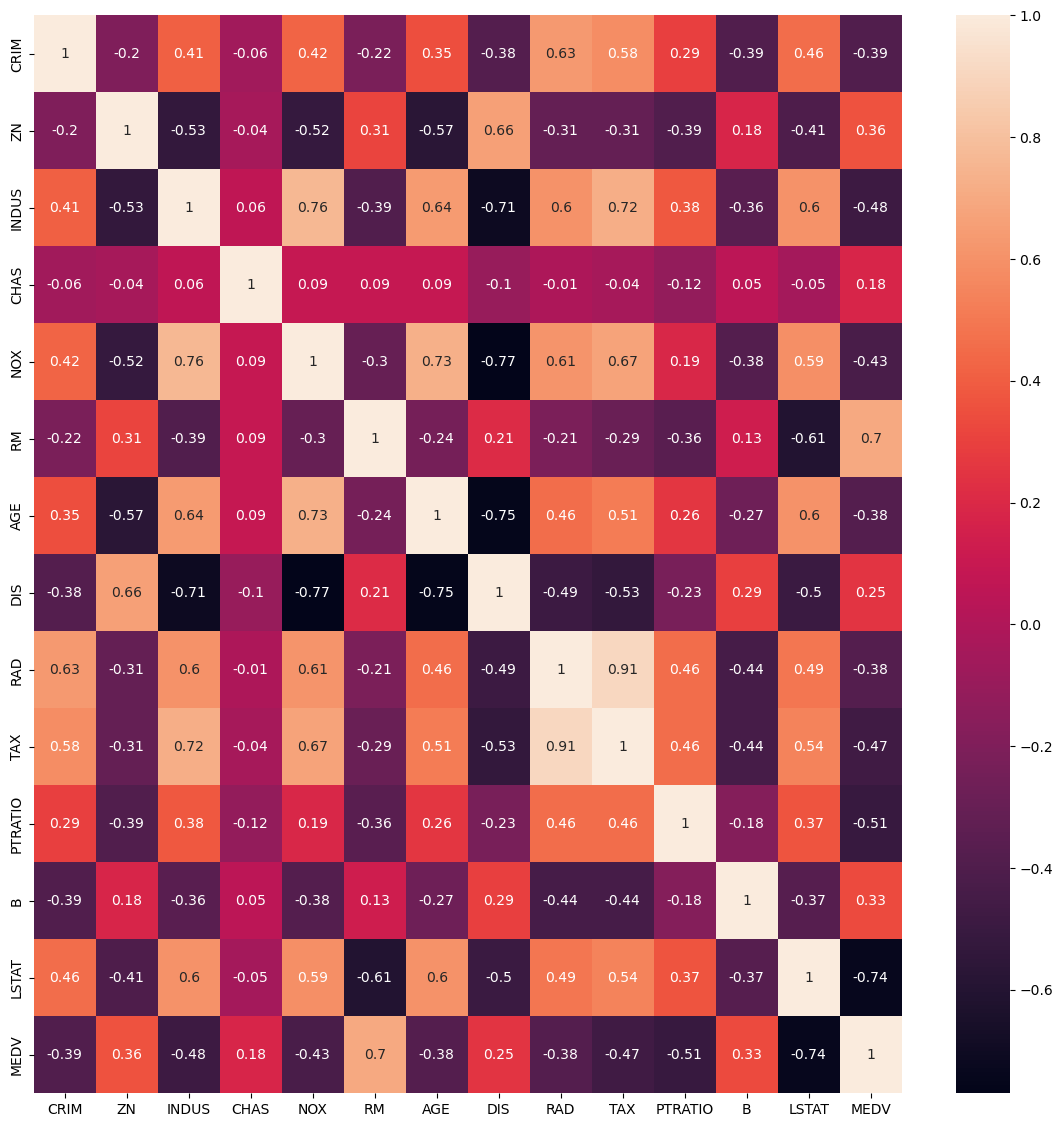

In [40]:
plt.figure(figsize=(14,14))
sns.heatmap(boston.corr().round(2), annot=True);

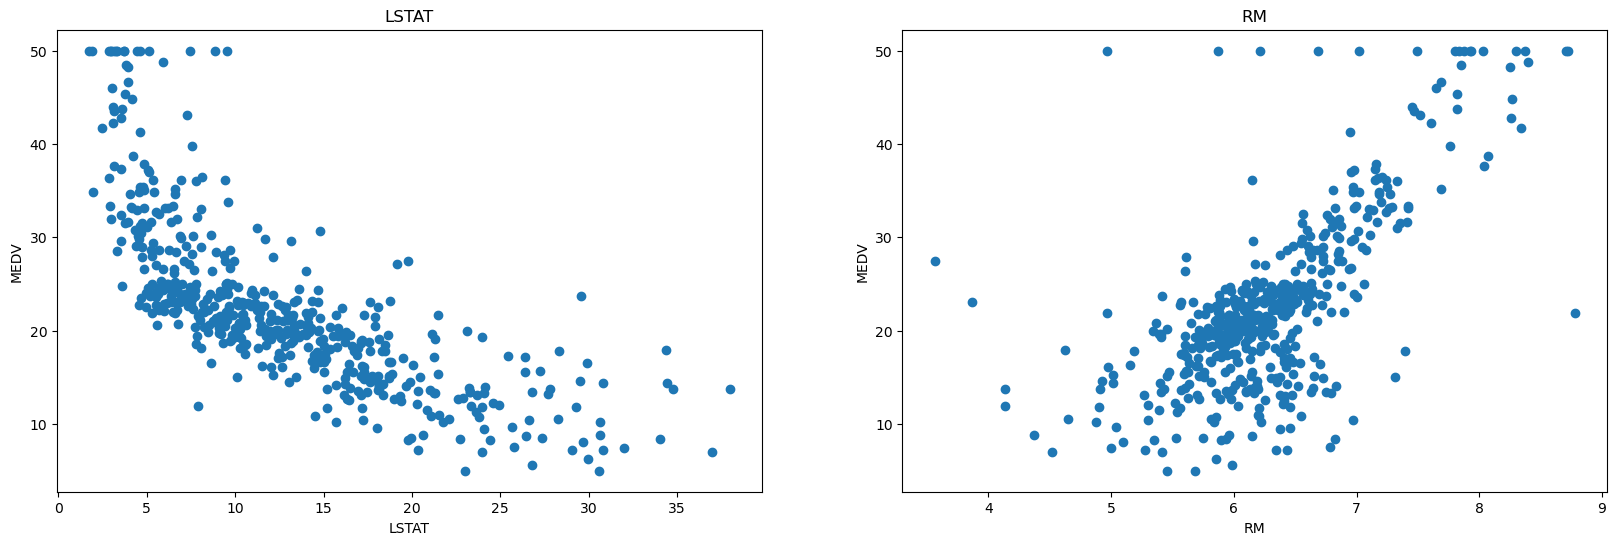

In [43]:
#### LSTAT vs MEDV && RM vs MEDV

def side_by_side(data, features_list, target):
    plt.figure(figsize=(20, 6))
    for i, col in enumerate(features_list):
        plt.subplot(1, len(features_list), i+1)
        x = boston[col]
        y = boston[target]
        plt.scatter(x, y, marker='o')
        plt.title(col)
        plt.xlabel(col)
        plt.ylabel(target)

features = ["LSTAT", "RM"]
target = "MEDV"

side_by_side(boston, features, target)

#### Prepare training data

In [45]:
# LSTAT, RM
X = boston[["LSTAT", "RM"]]
y = boston['MEDV']

#### Train-test split

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [49]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(339, 2)
(167, 2)
(339,)
(167,)


In [50]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics 

In [51]:
lm = LinearRegression()
lm.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:
predictions = lm.predict(X_test)

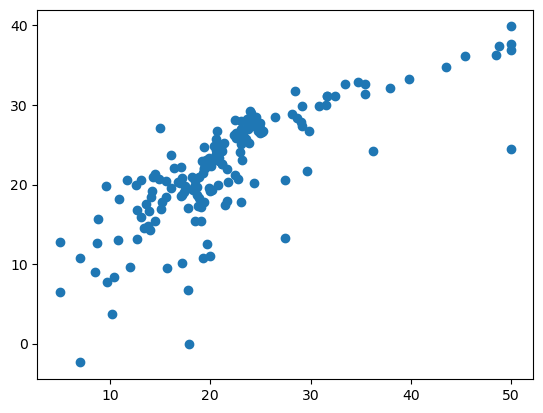

In [54]:
plt.scatter(y_test, predictions)
plt.show()

In [55]:
coef_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
coef_df

,Coefficient
LSTAT,-0.678739
RM,4.820356


##### Interpreting the results

- CP, a 1 unit increase in **LSTAT** is associated with a **decrease** of \$0.67
- CP, a 1 unit increase in **RM** is associated with an increase of \$ 4.82

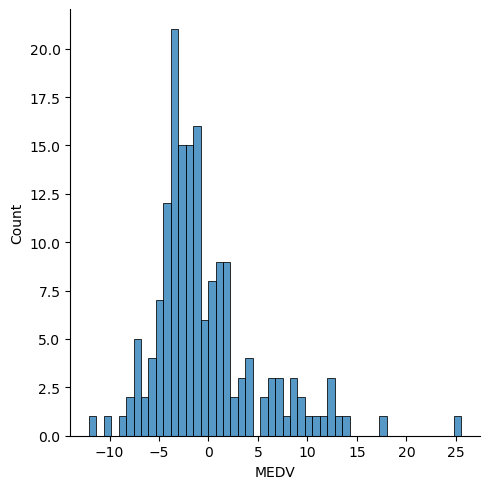

In [57]:
sns.displot((y_test - predictions), bins=50)
plt.show()

In [59]:
print("MAE", metrics.mean_absolute_error(y_test, predictions))
print("MSE", metrics.mean_squared_error(y_test, predictions))
print("RMSE", np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print("R2", metrics.r2_score(y_test, predictions))

MAE 4.019105583285631
MSE 28.97075021100662
RMSE 5.38244834726787
R2 0.6171865588521173
